# CITE-seq: RNA + protein

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ashford-A/UniVI/blob/main/docs/tutorials/citeseq.ipynb)

This tutorial uses the Hao et al. (2021) PBMC CITE-seq atlas (RNA plus 228 surface proteins, with three levels of cell-type annotation) and goes beyond the quickstart:

- a **fused** embedding that uses both modalities per cell
- **protein prediction from RNA** and **RNA prediction from protein**, checked marker by marker and cell type by cell type
- **denoising** RNA with information from protein
- **per-cell modality contributions**: how much each modality informs the fused embedding

The settings follow the CITE-seq analysis in the paper (Figs. 2–3). To keep the run short, the notebook works on a random subset of cells; set `MAX_CELLS = None` to use all of them.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q "univi[tutorials]>=1.0"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch

import univi.datasets as uds
from univi import ModalityConfig, TrainingConfig, UniVIConfig, UniVIMultiModalVAE, UniVITrainer
from univi.evaluation import (cross_modal_predict, denoise_adata, encode_adata, encode_fused_adata_pair,
                              encode_moe_gates_from_tensors, evaluate_alignment,
                              evaluate_cross_reconstruction, pearson_corr_per_feature)
from univi.plotting import (compare_raw_vs_denoised_umap_features, plot_moe_gate_summary,
                            plot_reconstruction_error_summary, write_gates_to_obs)
from univi.preprocessing import ADTPreprocessor, RNAPreprocessor, split_by_label
from univi.utils.seed import set_seed
from univi.workflows import make_loader, save_reference

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
set_seed(0)

C:\Users\ashfo\micromamba\envs\univi-release-050\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
N_EPOCHS = 400
BATCH_SIZE = 256
N_HVG = 2000
MAX_CELLS = 50_000   # None uses all ~162k cells

## Load and subsample

In [4]:
data = uds.hao_citeseq_pbmc()
rna, adt = data["rna"], data["adt"]
if MAX_CELLS is not None and rna.n_obs > MAX_CELLS:
    keep = np.sort(np.random.default_rng(0).choice(rna.n_obs, MAX_CELLS, replace=False))
    rna, adt = rna[keep].copy(), adt[keep].copy()
print(rna.shape, adt.shape)
rna.obs["celltype.l1"].value_counts()

(50000, 20729) (50000, 228)


celltype.l1
Mono       15123
CD4 T      12643
CD8 T       7856
NK          5811
B           4239
other T     2145
DC          1112
other       1071
Name: count, dtype: int64

## Split and preprocess

Protein counts are CLR-normalized per cell and then z-scored per protein with statistics from the training cells. RNA uses 2,000 highly variable genes selected on training cells.

In [5]:
splits = split_by_label(rna.obs["celltype.l2"], train_fraction=0.8, val_fraction=0.1, seed=0)
rna_prep = RNAPreprocessor(n_hvg=N_HVG, scale=True).fit(rna[splits["train"]])
adt_prep = ADTPreprocessor(scale=True).fit(adt[splits["train"]])
parts = {name: {"rna": rna_prep.transform(rna[idx]), "adt": adt_prep.transform(adt[idx])}
         for name, idx in splits.items()}
train, val, test = parts["train"], parts["val"], parts["test"]
{name: len(idx) for name, idx in splits.items()}

{'train': 39987, 'val': 4984, 'test': 5029}

## Train

In [6]:
cfg = UniVIConfig(
    latent_dim=30, beta=1.5, gamma=5.0,
    encoder_dropout=0.10, decoder_dropout=0.0,
    modalities=[
        ModalityConfig("rna", train["rna"].n_vars, [512, 256, 128], [128, 256, 512], likelihood="gaussian"),
        ModalityConfig("adt", train["adt"].n_vars, [128, 64], [64, 128], likelihood="gaussian"),
    ],
)
model = UniVIMultiModalVAE(cfg, loss_mode="v1", v1_recon="avg", normalize_v1_terms=True)
trainer = UniVITrainer(
    model,
    train_loader=make_loader(train, batch_size=BATCH_SIZE, shuffle=True, drop_last=True),
    val_loader=make_loader(val, batch_size=1024),
    train_cfg=TrainingConfig(n_epochs=N_EPOCHS, batch_size=BATCH_SIZE, lr=1e-3, weight_decay=1e-4,
                             device=device, early_stopping=True, patience=50, log_every=50),
)
history = trainer.fit()
print("best epoch:", trainer.best_epoch)

[2026-09-21 16:13:27,105] [UniVITrainer] [INFO] TrainingConfig:
[2026-09-21 16:13:27,107] [UniVITrainer] [INFO]   n_epochs: 400
[2026-09-21 16:13:27,107] [UniVITrainer] [INFO]   batch_size: 256
[2026-09-21 16:13:27,108] [UniVITrainer] [INFO]   lr: 0.001
[2026-09-21 16:13:27,108] [UniVITrainer] [INFO]   weight_decay: 0.0001
[2026-09-21 16:13:27,109] [UniVITrainer] [INFO]   device: 'cuda'
[2026-09-21 16:13:27,109] [UniVITrainer] [INFO]   log_every: 50
[2026-09-21 16:13:27,109] [UniVITrainer] [INFO]   grad_clip: None
[2026-09-21 16:13:27,110] [UniVITrainer] [INFO]   num_workers: 0
[2026-09-21 16:13:27,111] [UniVITrainer] [INFO]   seed: 0
[2026-09-21 16:13:27,112] [UniVITrainer] [INFO]   early_stopping: True
[2026-09-21 16:13:27,112] [UniVITrainer] [INFO]   patience: 50
[2026-09-21 16:13:27,113] [UniVITrainer] [INFO]   min_delta: 0.0
[2026-09-21 16:13:27,113] [UniVITrainer] [INFO]   best_epoch_warmup: 0
Training UniVI:   0%|          | 0/400 [00:00<?, ?it/s][2026-09-21 16:13:32,143] [UniVI

best epoch: 92


## A fused embedding from both modalities

`encode_fused_adata_pair` combines the RNA and protein posteriors of each cell into one latent point by precision-weighted fusion (modalities that are more certain about a cell contribute more). The result is written to `.obsm["X_univi_fused"]` of both test AnnData objects. Use this representation for clustering and annotation when every cell has all modalities.

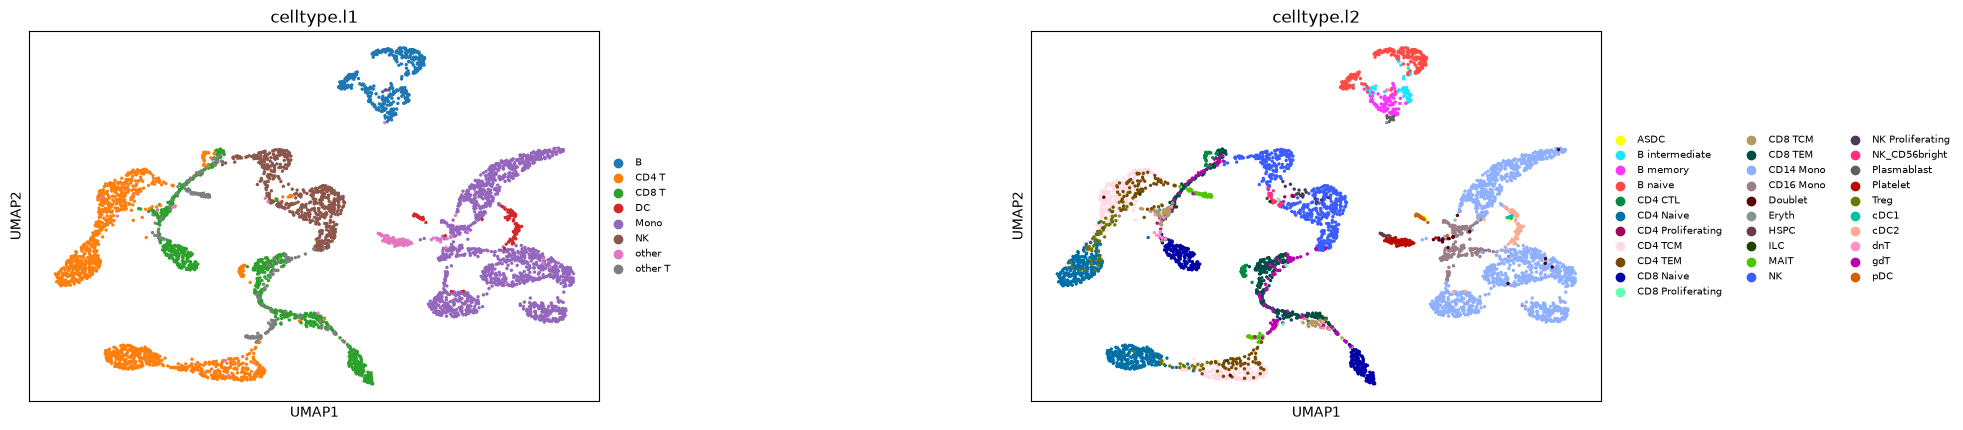

In [7]:
fused = encode_fused_adata_pair(model, adata_by_mod=test, device=device, fused_obsm_key="X_univi_fused")
rna_test, adt_test = test["rna"], test["adt"]
sc.pp.neighbors(rna_test, use_rep="X_univi_fused", n_neighbors=30)
sc.tl.umap(rna_test, random_state=0)
adt_test.obsm["X_umap"] = rna_test.obsm["X_umap"]  # same cells, same coordinates
sc.pl.umap(rna_test, color=["celltype.l1", "celltype.l2"], wspace=0.6, legend_fontsize=7)

The per-modality embeddings are still available and still aligned:

In [8]:
z_rna = encode_adata(model, rna_test, modality="rna", device=device, latent="modality_mean")
z_adt = encode_adata(model, adt_test, modality="adt", device=device, latent="modality_mean")
labels = rna_test.obs["celltype.l2"].astype(str).to_numpy()
m = evaluate_alignment(Z1=z_rna, Z2=z_adt, labels_source=labels, labels_target=labels)
print(f"FOSCTTM {m['foscttm_mean']:.3f}   label transfer (celltype.l2) accuracy {m['label_transfer_acc']:.3f}")

FOSCTTM 0.015   label transfer (celltype.l2) accuracy 0.890


## Predict protein from RNA

Encoding RNA and decoding with the protein decoder predicts every protein for every cell (values are in the preprocessed space: CLR, then z-scored).

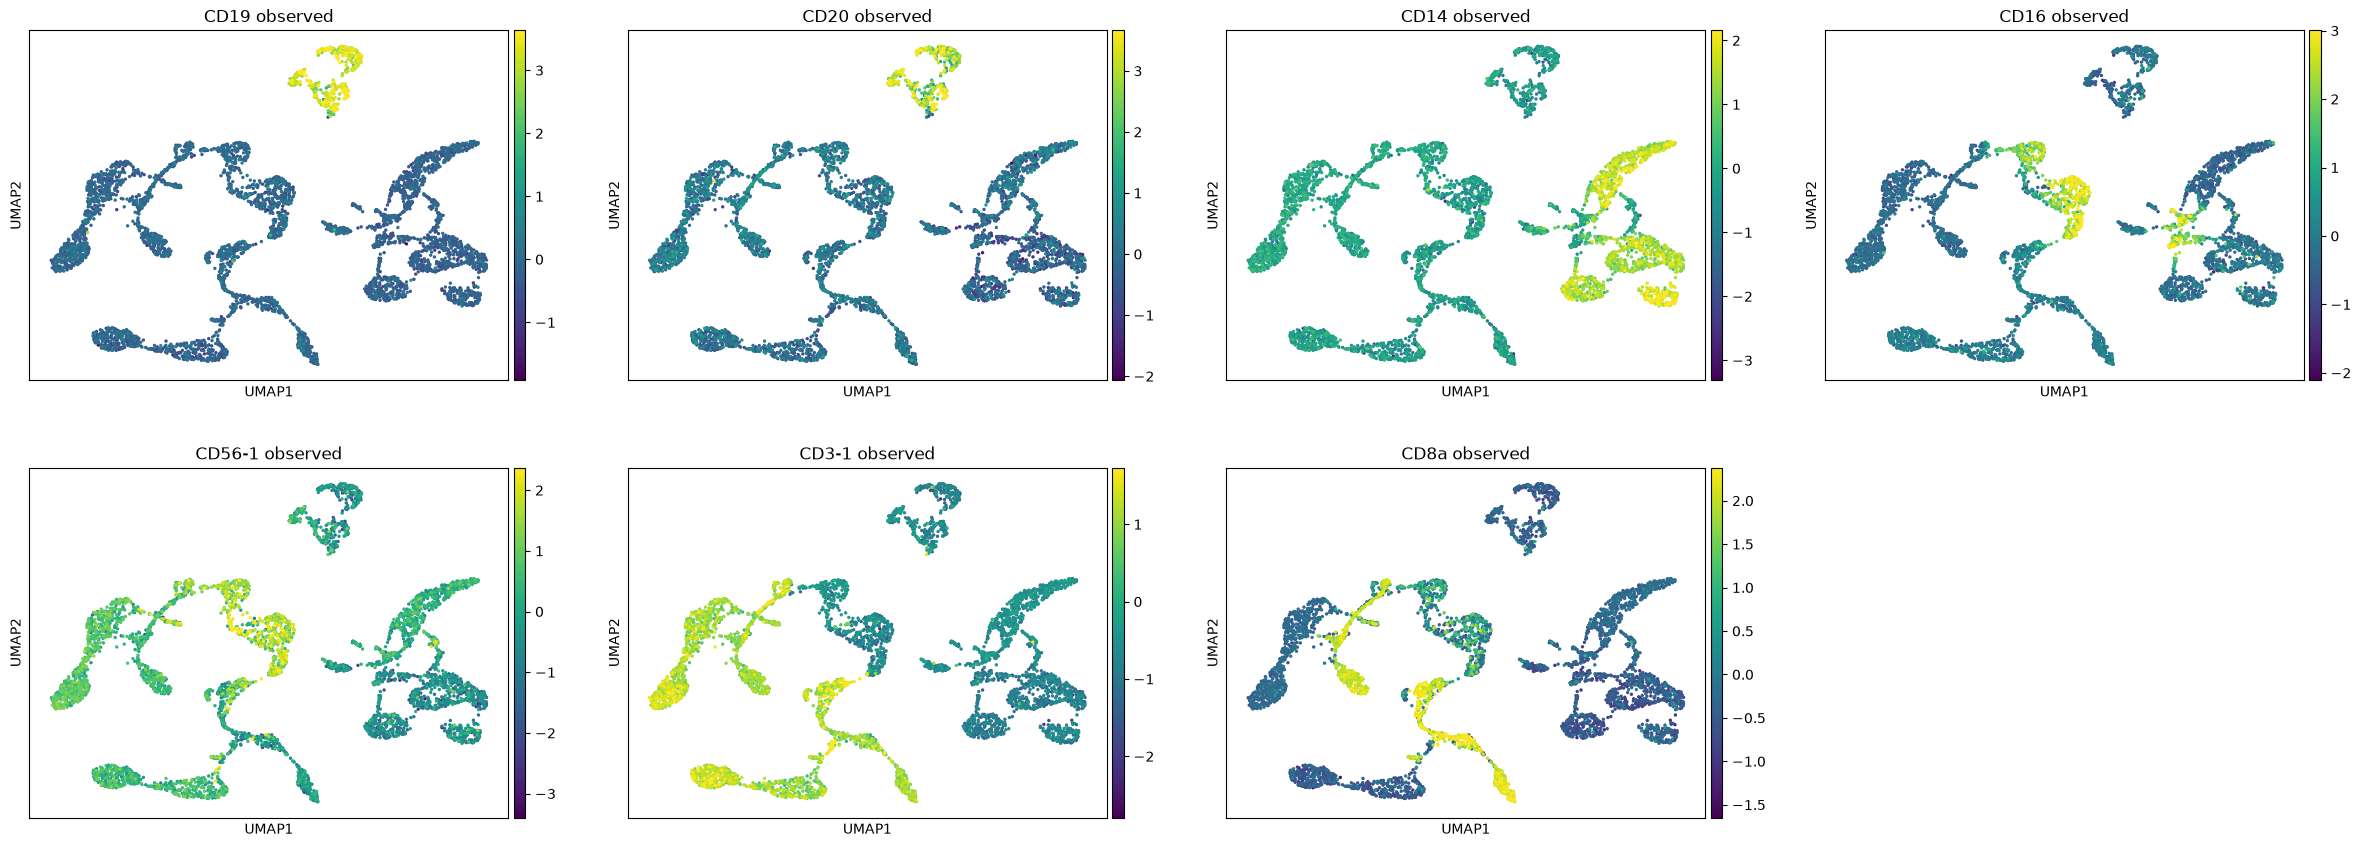

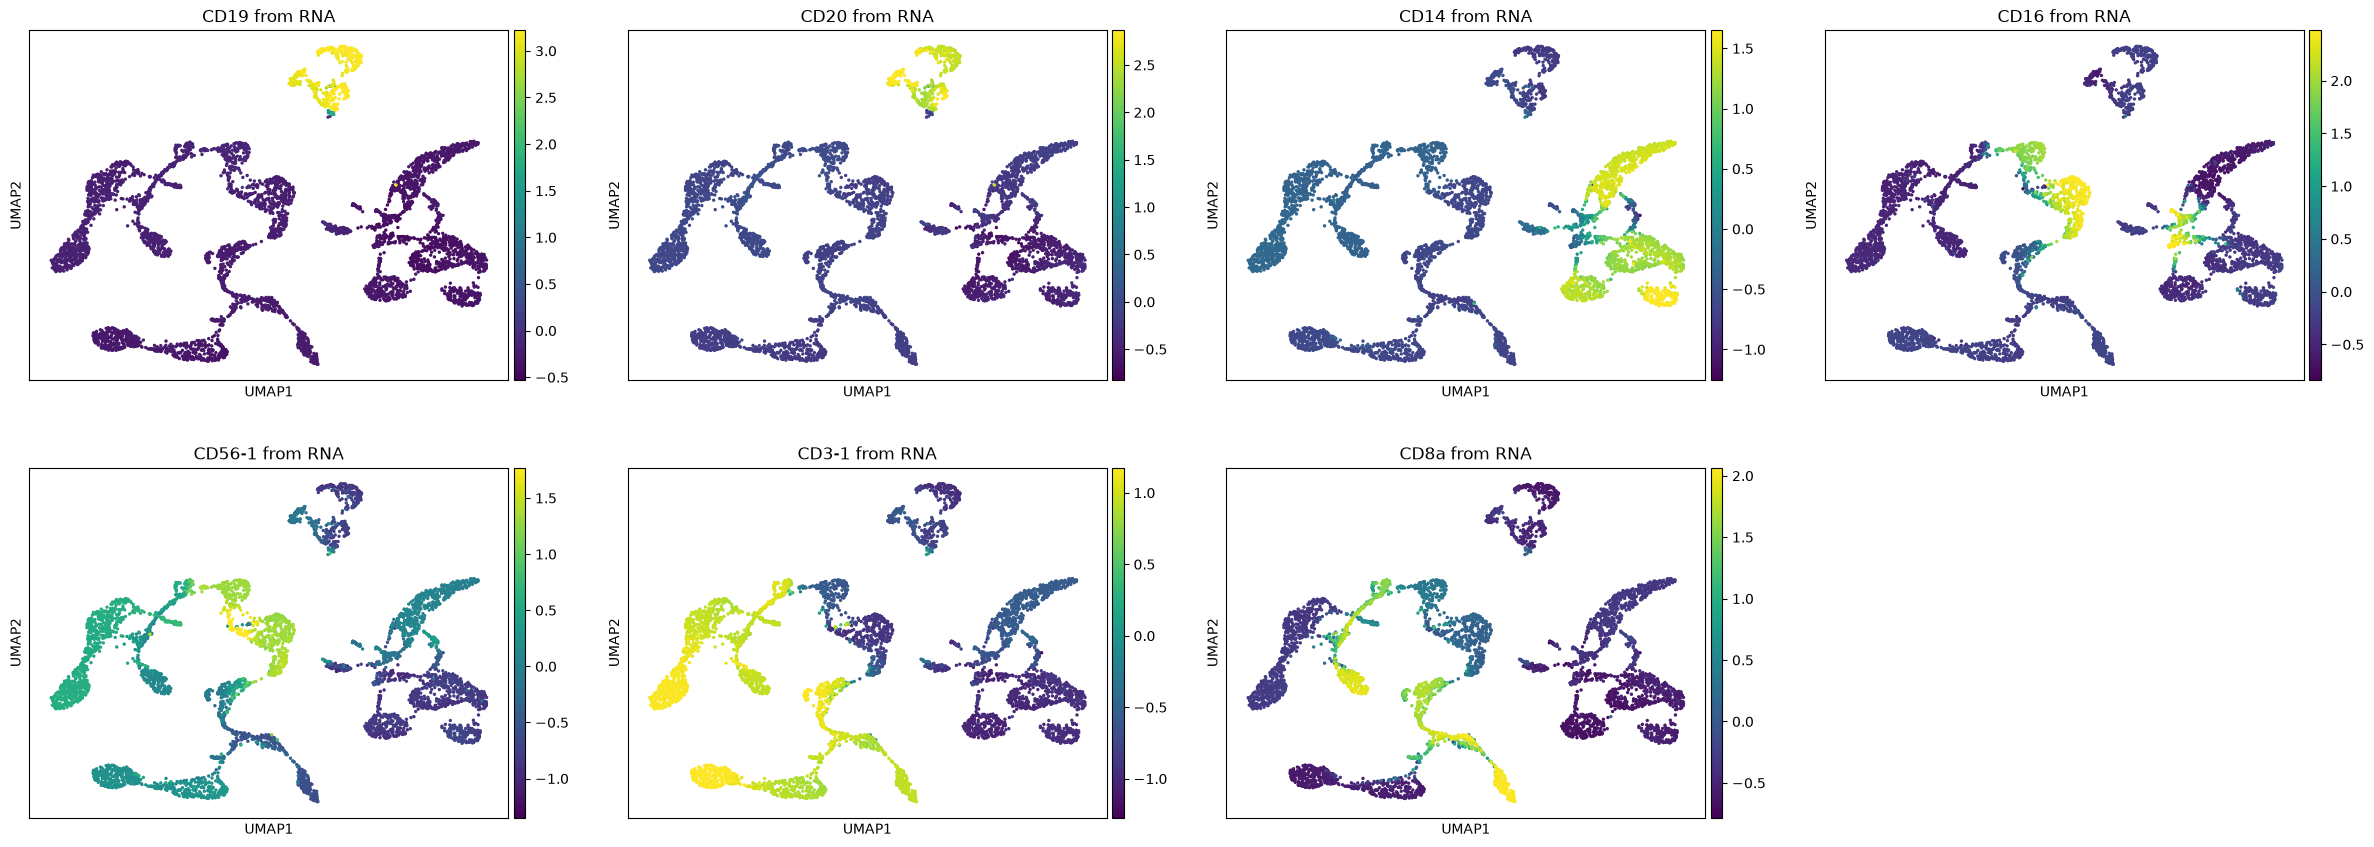

In [9]:
adt_test.layers["from_rna"] = cross_modal_predict(model, rna_test, src_mod="rna", tgt_mod="adt", device=device)

proteins = [p for p in ["CD19", "CD20", "CD14", "CD16", "CD56-1", "CD3-1", "CD4", "CD8a"] if p in adt_test.var_names]
sc.pl.umap(adt_test, color=proteins, ncols=4, vmax="p99", cmap="viridis",
           title=[f"{p} observed" for p in proteins])
sc.pl.umap(adt_test, color=proteins, ncols=4, layer="from_rna", vmax="p99", cmap="viridis",
           title=[f"{p} from RNA" for p in proteins])

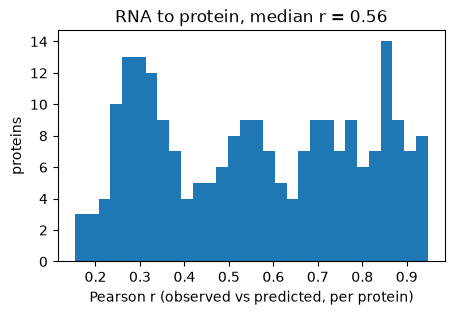

CD2        0.915
CD307e     0.920
CD64       0.921
CD31       0.921
CD11b-2    0.922
CD4-1      0.928
CD3-1      0.928
CD19       0.937
CD3-2      0.944
CLEC12A    0.947
dtype: float32

In [10]:
r_protein = pd.Series(pearson_corr_per_feature(np.asarray(adt_test.X), adt_test.layers["from_rna"]),
                      index=adt_test.var_names).sort_values()
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(r_protein.dropna(), bins=30)
ax.set(xlabel="Pearson r (observed vs predicted, per protein)", ylabel="proteins",
       title=f"RNA to protein, median r = {r_protein.median():.2f}")
plt.show()
r_protein.tail(10).round(3)

Cell-type means are a more forgiving and often more relevant check: do predicted proteins rise and fall across cell types the way the measured ones do?

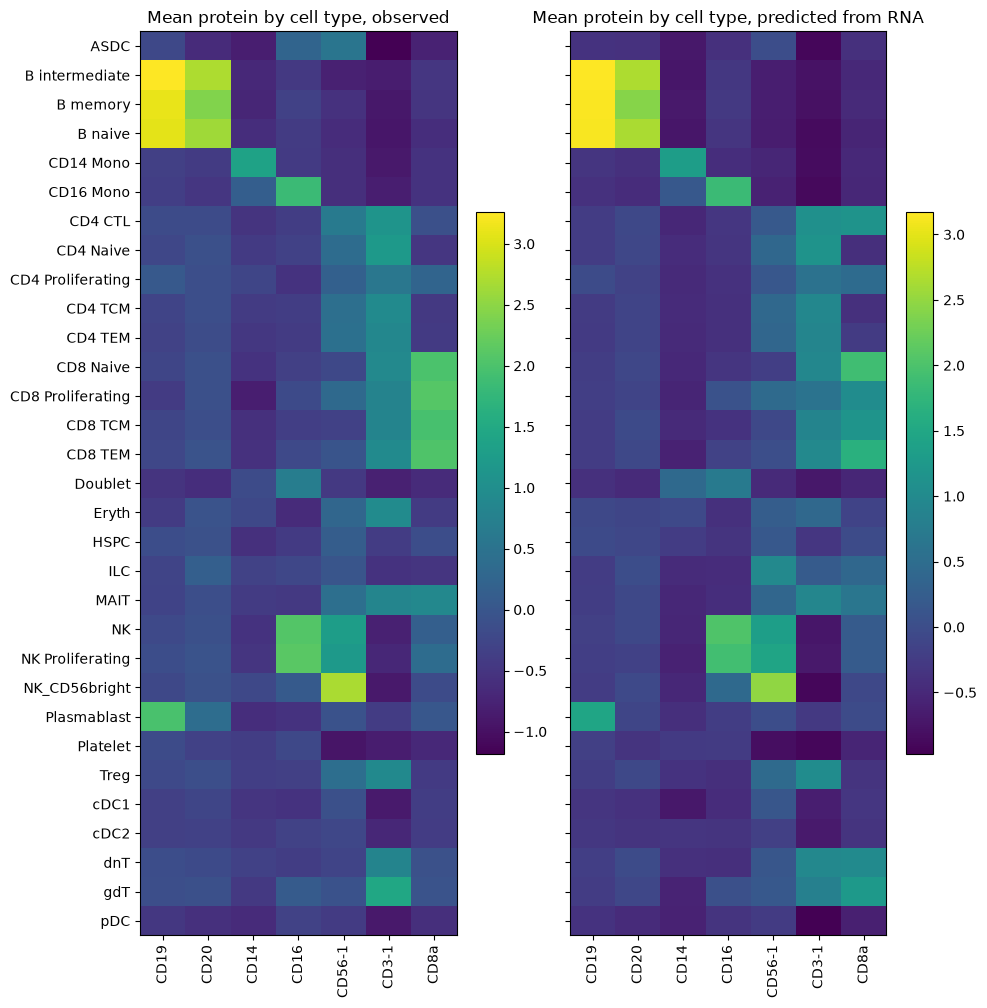

In [11]:
group = adt_test.obs["celltype.l2"].astype(str)
obs_means = pd.DataFrame(np.asarray(adt_test[:, proteins].X), columns=proteins).groupby(group.values).mean()
pred_means = pd.DataFrame(adt_test[:, proteins].layers["from_rna"], columns=proteins).groupby(group.values).mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 0.28 * len(obs_means) + 1.5), sharey=True)
for ax, table, title in zip(axes, [obs_means, pred_means], ["observed", "predicted from RNA"]):
    im = ax.imshow(table.values, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(proteins)), proteins, rotation=90)
    ax.set_yticks(range(len(table)), table.index)
    ax.set_title(f"Mean protein by cell type, {title}")
    fig.colorbar(im, ax=ax, shrink=0.6)
plt.tight_layout()
plt.show()

## Predict RNA from protein

`evaluate_cross_reconstruction` bundles prediction and per-feature error metrics. Genes that surface proteins cannot inform (for example many housekeeping and cell-cycle genes) show up among the worst-predicted.

{'mse_mean': 0.781, 'mse_median': 0.764, 'pearson_mean': 0.374, 'pearson_median': 0.369, 'per_cell_mean': 0.781}


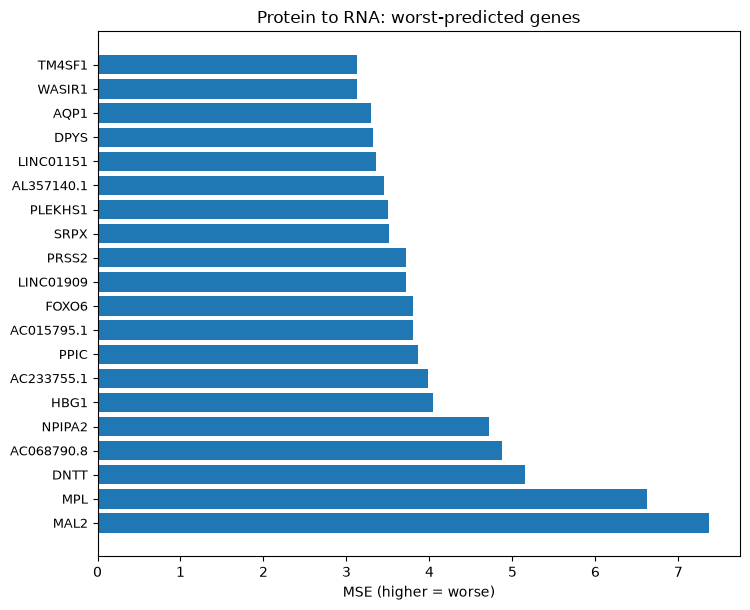

In [12]:
rep = evaluate_cross_reconstruction(model, adt_test, rna_test, src_mod="adt", tgt_mod="rna", device=device)
print({k: round(float(v), 3) for k, v in rep["summary"].items()})
plot_reconstruction_error_summary(rep, metric="mse", top_k=20, title="Protein to RNA: worst-predicted genes")

## Denoise RNA using both modalities

Denoising encodes a cell (here with both RNA and protein), then decodes RNA. It smooths technical noise such as dropout; it also smooths genuine cell-to-cell variation, so use it for visualization and marker inspection rather than as a replacement for the measured data in statistical tests.

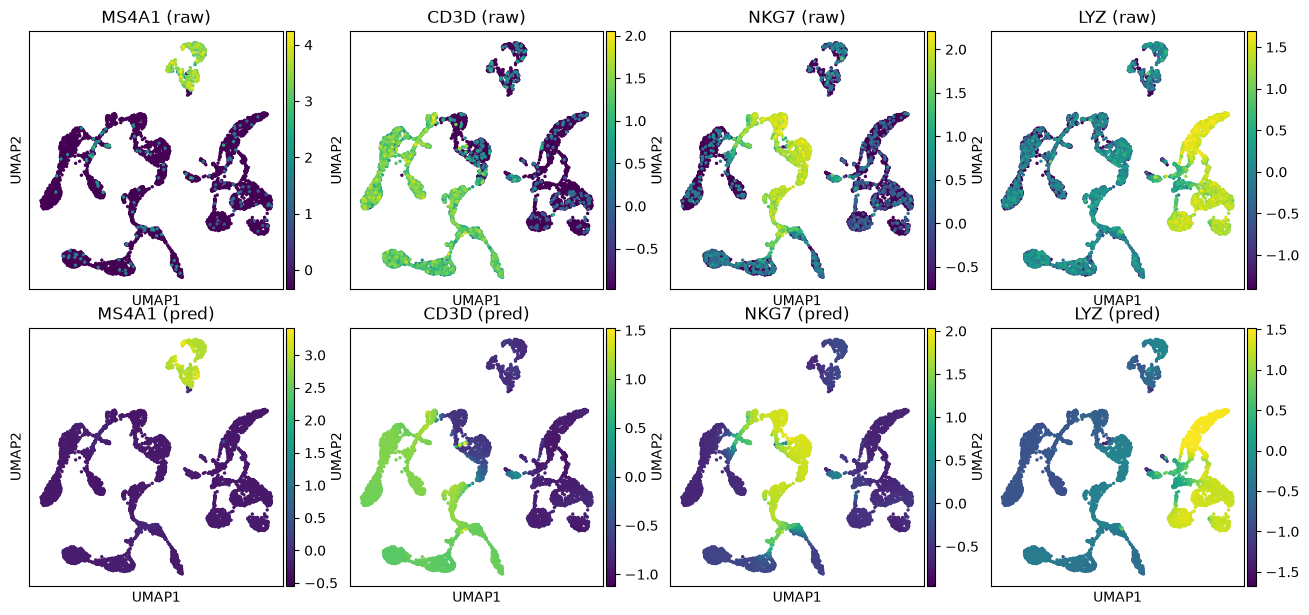

In [13]:
denoise_adata(model, rna_test, modality="rna", device=device, out_layer="denoised",
              adata_by_mod=test)
genes = [g for g in ["MS4A1", "CD3D", "NKG7", "LYZ"] if g in rna_test.var_names]
rna_test.obsm["X_univi"] = rna_test.obsm["X_univi_fused"]
compare_raw_vs_denoised_umap_features(rna_test, obsm_key="X_univi", features=genes, denoised_layer="denoised")

## How much does each modality contribute?

The fused posterior is a precision-weighted average of the per-modality posteriors. `kind="effective_precision"` sums each modality's posterior precision over latent dimensions and normalizes across modalities, giving one weight per modality per cell. Cell types where protein is especially informative (well-separated surface markers) lean more on ADT.

{'rna': 0.4999002516269684, 'adt': 0.500099778175354}


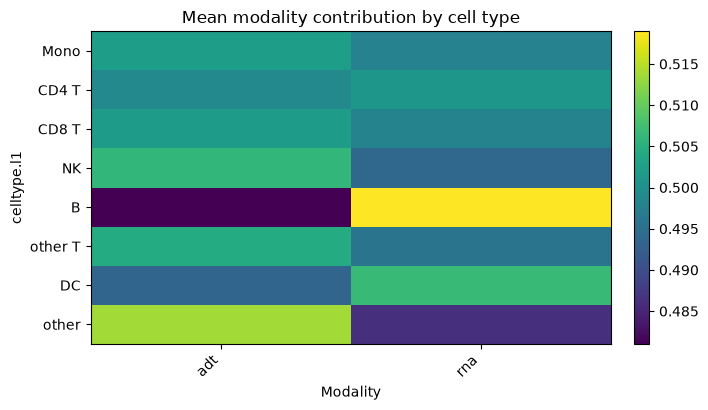

In [14]:
gates = encode_moe_gates_from_tensors(
    model, {"rna": rna_test.X, "adt": adt_test.X}, device=device, kind="effective_precision")
write_gates_to_obs(rna_test, gates["weights"], modality_names=gates["modality_order"], gate_prefix="weight")
print(gates["per_modality_mean"])
plot_moe_gate_summary(rna_test, gate_prefix="weight", groupby="celltype.l1",
                      title="Mean modality contribution by cell type")

UniVI can also learn a small gating network (`UniVIConfig(use_moe_gating=True)`) that re-weights modalities per cell. That network is trained only when the fused posterior is part of the loss, i.e. with `v1_recon="moe"` or `loss_mode="v2"`; see the [model guide](../user_guide/model.md#modality-weights-and-gating).

## Save

In [15]:
save_reference("univi_citeseq_reference", model, preprocessors={"rna": rna_prep, "adt": adt_prep},
               metadata={"dataset": "hao_citeseq_pbmc", "max_cells": MAX_CELLS})